# 01. Perfilado Inicial de Datos

Este notebook realiza el diagnóstico inicial de las dos fuentes de datos del Sunset Hospitality Group:
1. **Sistema Interno (`internal_bookings.csv`)**: Datos originales del hotel.
2. **Canales Externos (`external_bookings.csv`)**: Datos simulados de agencias, con ruido inyectado, columnas en español, inconsistencias de formato y nombres alterados.

**Objetivo:** 
Generar reportes automatizados de calidad y calcular las métricas iniciales (Completitud, Consistencia, Unicidad y Validez) que formarán nuestra base comparativa (baseline) para el Índice de Calidad de Datos (DQS).

In [11]:
import pandas as pd
import missingno as msno
import json
import os
import sweetviz as sv

# Configuración de rutas estandarizadas
RAW_PATH = '../data/raw/'
RESULTS_PATH = '../data/results/'

## 1. Carga de las Fuentes de Datos
Leemos ambos archivos CSV desde la capa `raw`.

In [12]:
df_internal = pd.read_csv(os.path.join(RAW_PATH, 'internal_bookings.csv'))
df_external = pd.read_csv(os.path.join(RAW_PATH, 'external_bookings.csv'))

print(f"Dimensión Sistema Interno: {df_internal.shape[0]} filas, {df_internal.shape[1]} columnas")
print(f"Dimensión Canales Externos: {df_external.shape[0]} filas, {df_external.shape[1]} columnas")

Dimensión Sistema Interno: 119390 filas, 36 columnas
Dimensión Canales Externos: 119390 filas, 33 columnas


### 1.1 Exploración Detallada de Nulos
Identificamos específicamente qué columnas tienen valores faltantes y en qué proporción.

In [13]:
def get_null_report(df):
    null_counts = df.isnull().sum()
    null_pct = (null_counts / len(df)) * 100
    report = pd.DataFrame({
        'Columna': df.columns,
        'Nulos': null_counts.values,
        'Porcentaje (%)': null_pct.values
    })
    return report[report['Nulos'] > 0].sort_values(by='Porcentaje (%)', ascending=False)

print("--- Nulos en Sistema Interno ---")
display(get_null_report(df_internal))

print("\n--- Nulos en Canales Externos ---")
display(get_null_report(df_external))

--- Nulos en Sistema Interno ---


,Columna,Nulos,Porcentaje (%)
24,company,112593,94.306893
23,agent,16340,13.686238
13,country,488,0.408744
10,children,4,0.003350



--- Nulos en Canales Externos ---


,Columna,Nulos,Porcentaje (%)
20,company,112593,94.306893
19,agent,16340,13.686238
9,pais_origen,6480,5.427590
16,assigned_room_type,6157,5.157048
3,stays_in_weekend_nights,6020,5.042298
6,children,6012,5.035598
4,stays_in_week_nights,6007,5.031410
5,adults,5996,5.022196
8,meal,5967,4.997906
18,tipo_deposito,5953,4.986180


### 1.2 Estadísticas Rápidas de Variables Clave
Exploramos los rangos de las variables numéricas principales.

In [14]:
print("Resumen Estadístico (Variables Numéricas - Externo):")
cols_interes = ['dias_anticipacion', 'tarifa_diaria_promedio', 'total_solicitudes_especiales']
display(df_external[cols_interes].describe())

Resumen Estadístico (Variables Numéricas - Externo):


,dias_anticipacion,tarifa_diaria_promedio,total_solicitudes_especiales
count,113566.000000,113438.000000,119390.000000
mean,104.044186,101.819696,0.571363
std,106.815018,50.640497,0.792798
min,0.000000,-6.380000,0.000000
25%,18.000000,69.300000,0.000000
50%,69.000000,94.500000,0.000000
75%,161.000000,126.000000,1.000000
max,737.000000,5400.000000,5.000000


## 2. Generación de Reportes Automáticos (sweetviz)
Exportamos un perfilado completo en HTML para documentar distribuciones y correlaciones.

In [15]:
# Perfilado para la fuente interna
report_int = sv.analyze(df_internal)
report_int.show_html(os.path.join(RESULTS_PATH, 'initial_internal_profiling.html'), open_browser=False)

# Perfilado para la fuente externa
report_ext = sv.analyze(df_external)
report_ext.show_html(os.path.join(RESULTS_PATH, 'initial_external_profiling.html'), open_browser=False)

print("[OK] Reportes HTML exportados exitosamente a data/results/")

Done! Use 'show' commands to display/save.   |██████████| [100%]   00:03 -> (00:00 left)


Report ../data/results/initial_internal_profiling.html was generated.


Done! Use 'show' commands to display/save.   |██████████| [100%]   00:00 -> (00:00 left)

Report ../data/results/initial_external_profiling.html was generated.
[OK] Reportes HTML exportados exitosamente a data/results/


## 3. Análisis Visual de Nulos (missingno)
Visualizamos la densidad de valores faltantes.

Distribución de valores nulos - Canales Externos


<Axes: >

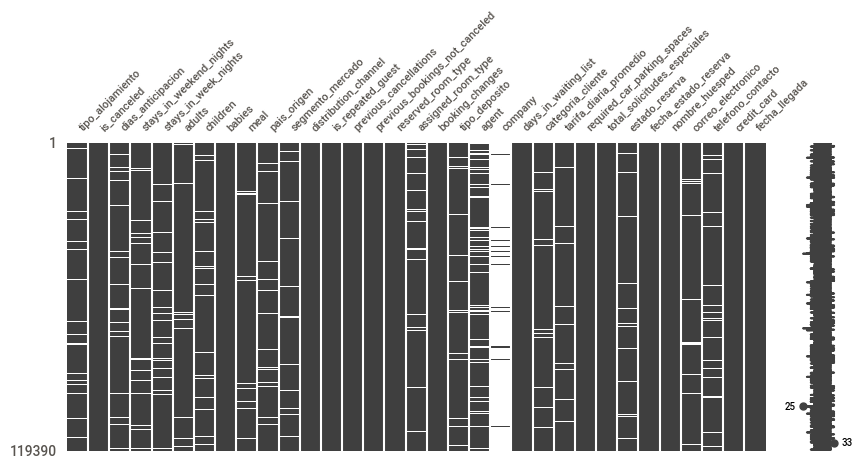

In [16]:
print("Distribución de valores nulos - Canales Externos")
msno.matrix(df_external, figsize=(10, 4), fontsize=8)

## 4. Cálculo de Métricas DQS Iniciales
Cuantificamos la calidad actual para evaluar el progreso tras el pipeline de limpieza.

In [17]:
def calculate_metrics(df, is_external=False):
    metrics = {}
    total_cells = df.size
    total_rows = len(df)
    
    # 1. Completitud (% de celdas no nulas)
    metrics['completeness'] = (df.notnull().sum().sum() / total_cells) * 100
    
    # 2. Unicidad (% de registros sin duplicados exactos)
    metrics['uniqueness'] = (1 - (df.duplicated().sum() / total_rows)) * 100
    
    # 3. Consistencia (Formato de fecha YYYY-MM-DD)
    if is_external:
        regex_iso = r'^\d{4}-\d{2}-\d{2}$'
        valid_dates = df['fecha_llegada'].dropna().astype(str).str.match(regex_iso).sum()
    else:
        valid_dates = 0 
        
    metrics['consistency'] = (valid_dates / total_rows) * 100
    
    # 4. Validez (Rangos lógicos: lead_time 0-365, ADR 0-1000)
    lt_col = 'dias_anticipacion' if is_external else 'lead_time'
    adr_col = 'tarifa_diaria_promedio' if is_external else 'adr'
    
    valid_lt = df[lt_col].dropna().between(0, 365).sum()
    valid_adr = df[adr_col].dropna().between(0, 1000).sum()
    
    metrics['validity'] = ((valid_lt + valid_adr) / (2 * total_rows)) * 100
    
    return metrics

# Calculamos métricas por fuente
m_internal = calculate_metrics(df_internal, is_external=False)
m_external = calculate_metrics(df_external, is_external=True)

### 4.1 Consolidación y Exportación
Agrupamos las métricas para el baseline del negocio.

In [18]:
initial_metrics = {
    "completitud": round((m_internal['completeness'] + m_external['completeness']) / 2, 2),
    "consistencia": round((m_internal['consistency'] + m_external['consistency']) / 2, 2),
    "unicidad": round((m_internal['uniqueness'] + m_external['uniqueness']) / 2, 2),
    "validez": round((m_internal['validity'] + m_external['validity']) / 2, 2)
}

print("Métricas de Calidad de Datos (Baseline):")
print(json.dumps(initial_metrics, indent=4))

# Guardamos los resultados para uso futuro
with open(os.path.join(RESULTS_PATH, 'initial_metrics.json'), 'w') as f:
    json.dump(initial_metrics, f, indent=4)

print("[OK] Métricas iniciales guardadas.")

Métricas de Calidad de Datos (Baseline):
{
    "completitud": 95.64,
    "consistencia": 0.0,
    "unicidad": 100.0,
    "validez": 96.25
}
[OK] Métricas iniciales guardadas.
